In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

In [8]:
data = pd.read_csv("./DATA/spam_ham.csv")
data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [9]:
data.shape

(5728, 2)

In [34]:
data['spam'].value_counts()

spam
0    4327
1    1368
Name: count, dtype: int64

<Axes: xlabel='spam', ylabel='count'>

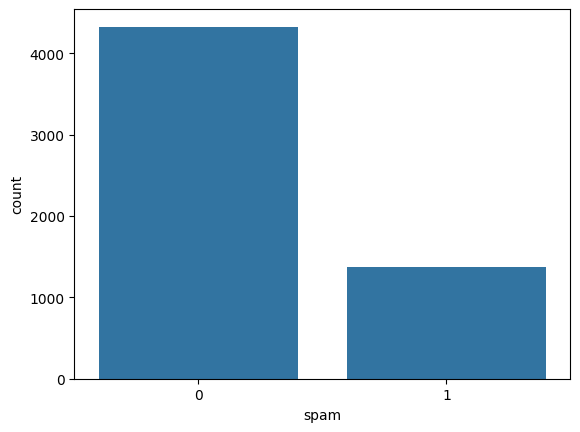

In [35]:
sns.countplot(data=data, x='spam')

In [36]:
data.duplicated().sum()

np.int64(0)

In [37]:
data.drop_duplicates(inplace=True)

<Axes: xlabel='spam', ylabel='count'>

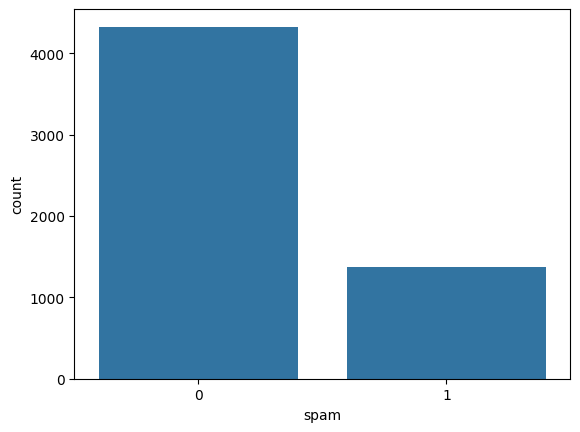

In [38]:
sns.countplot(data=data, x='spam')

In [39]:
X = data['text'].values
y = data['spam'].values

In [41]:
y

array([1, 1, 1, ..., 0, 0, 0], shape=(5695,))

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2 , random_state= 0)

In [51]:
X_train.shape, y_train.shape

((4556,), (4556,))

In [50]:
X_test.shape, y_test.shape

((1139,), (1139,))

In [58]:
cv = CountVectorizer()
nb = MultinomialNB()
pipe = make_pipeline(cv, nb)

In [59]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('countvectorizer', CountVectorizer()),
                ('multinomialnb', MultinomialNB())])

In [60]:
y_pred = pipe.predict(X_test)

In [62]:
accuracy_score(y_pred, y_test)

0.990342405618964

In [76]:
def spam_ham(prediction):
    if(prediction[0] == 1): 
        print("SPAM")
    else: 
        print("HAM")

In [77]:
email = ['Just a quick reminder about our meeting scheduled for tomorrow at 10 AM in the conference room. Let me know if you need to reschedule.']
spam_ham(pipe.predict(email))

HAM


In [79]:
email = ['You have been selected as a lucky winner of a brand new iPhone 15!Claim your prize now by clicking the link below:']
spam_ham(pipe.predict(email))

SPAM
